# 05c — CLEAR Counterfactual FoldX and Structural Validation

## Obiettivo

Questo notebook valida strutturalmente il pannello di controfattuali prodotto dal 04e.

Input:

```text
outputs/clear_peptide_counterfactuals_04e/
    validation_panel/
        clear_counterfactual_validation_panel.csv
        clear_validation_individual_list.txt
```

Seed di riferimento:

```text
F0010 — IGERCQYRDLK
```

Il notebook:

1. recupera il complesso nativo F0010;
2. importa i 10 controfattuali CLEAR;
3. esegue FoldX `BuildModel`;
4. associa correttamente i PDB mutanti ai candidati;
5. recupera il ΔΔG FoldX;
6. calcola:
   - contatti atomici;
   - contatti residuo-residuo;
   - ritenzione dei contatti nativi;
   - precisione dei contatti;
   - conservazione dei contatti hotspot;
   - clash;
   - deviazione geometrica del peptide;
7. confronta ogni candidato con F0010;
8. produce un ranking finale per selezionare 3–5 candidati da sottoporre a Rosetta FlexPepDock.

## Nota metodologica

FoldX `BuildModel` valuta le mutazioni nella posa derivata dal complesso nativo.  
I risultati non dimostrano binding autonomo: servono come filtro energetico-strutturale prima del refinement Rosetta.


## 1. Dipendenze

```bash
pip install pandas numpy matplotlib biopython
```


In [1]:
from pathlib import Path
from collections import Counter
import json
import math
import os
import re
import shutil
import subprocess
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio.PDB import PDBParser, NeighborSearch, Superimposer, is_aa

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)

print("Ambiente inizializzato.")

Ambiente inizializzato.


## 2. Configurazione

In [9]:
OUTPUT_DIR = Path("outputs")

CLEAR_04E_DIR = OUTPUT_DIR / "clear_peptide_counterfactuals_04e"
VALIDATION_INPUT_DIR = CLEAR_04E_DIR / "validation_panel"

VALIDATION_PANEL_CSV = (
    VALIDATION_INPUT_DIR
    / "clear_counterfactual_validation_panel.csv"
)
MUTATION_LIST_TXT = (
    VALIDATION_INPUT_DIR
    / "clear_validation_individual_list.txt"
)

SOURCE_03C_DIR = OUTPUT_DIR / "short_peptide_guided_docking_03c"

NATIVE_PDB_CANDIDATES = [
    SOURCE_03C_DIR
    / "rosetta_flexpepdock"
    / "inputs"
    / "F0010.pdb",
    SOURCE_03C_DIR
    / "inputs"
    / "F0010_native_complex.pdb",
    OUTPUT_DIR
    / "short_peptide_structural_ranking"
    / "native_fragment_complexes"
    / "F0010_BD_D38-48.pdb",
]

RESULT_DIR = OUTPUT_DIR / "clear_counterfactual_validation_05c"
FOLDX_DIR = RESULT_DIR / "foldx_buildmodel"
MODELS_DIR = RESULT_DIR / "counterfactual_models"
REPORTS_DIR = RESULT_DIR / "reports"
ROSETTA_PREP_DIR = RESULT_DIR / "rosetta_candidates"

for directory in [
    RESULT_DIR,
    FOLDX_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    ROSETTA_PREP_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

SEED_SEQUENCE = "IGERCQYRDLK"
RECEPTOR_CHAIN = "B"
PEPTIDE_CHAIN = "D"
PEPTIDE_START_RESSEQ = 38
PEPTIDE_END_RESSEQ = 48

CONTACT_CUTOFF_A = 4.5
CLASH_CUTOFF_A = 2.0

RUN_FOLDX = True
SKIP_IF_COMPLETE = True
BACKUP_INCOMPLETE_OUTPUTS = True

TOP_N_FOR_ROSETTA = 5

FOLDX_CANDIDATES = [
    shutil.which("foldx"),
    shutil.which("FoldX"),
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx",
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/FoldX",
    "/Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231",
]

print("Input panel:", VALIDATION_PANEL_CSV.resolve())
print("Output:", RESULT_DIR.resolve())

Input panel: /Users/robertobruzzese/Desktop/venv/outputs/clear_peptide_counterfactuals_04e/validation_panel/clear_counterfactual_validation_panel.csv
Output: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c


## 3. Controllo degli input

In [10]:
for required in [VALIDATION_PANEL_CSV, MUTATION_LIST_TXT]:
    if not required.exists():
        raise FileNotFoundError(
            f"File mancante: {required}. Eseguire prima il 04e."
        )

validation_panel = pd.read_csv(VALIDATION_PANEL_CSV)

required_columns = {
    "validation_id",
    "sequence",
    "mutation_labels",
    "prediction",
    "predicted_improvement_vs_seed",
    "foldx_mutation_string",
}

missing = required_columns - set(validation_panel.columns)

if missing:
    raise ValueError(
        "Colonne mancanti: " + ", ".join(sorted(missing))
    )

display(validation_panel)

,validation_id,clear_rank,source,restart,best_step,sequence,prediction,predicted_improvement_vs_seed,n_mutations,mutation_labels,valid,validity_status,optimization_objective,depth,counterfactual_success,present_in_04c_library,present_in_04c_labeled,is_novel_sequence,min_hamming_to_labeled_data,local_support_class,minimality_score,novelty_bonus,support_score,normalized_predicted_improvement,clear_final_score,foldx_mutation_string
0,CF_01,22,beam_clear,NaN,NaN,IGERCEYKDLK,0.772116,0.026186,2,Q6E;R8K,True,PASS,-0.013814,2.0,True,False,False,True,1,strong_local_support,0.333333,1.0,0.5,0.904937,0.783456,"QD43E,RD45K;"
1,CF_02,1,beam_clear,NaN,NaN,IGERSQYRELK,0.841685,0.095755,2,C5S;D9E,True,PASS,0.055755,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,1.000000,0.850000,"CD42S,DD46E;"
2,CF_03,2,beam_clear,NaN,NaN,IGERCQYRELK,0.808901,0.062971,1,D9E,True,PASS,0.042971,1.0,True,True,True,False,0,observed,0.500000,0.0,1.0,0.955202,0.843641,DD46E;
3,CF_04,3,beam_clear,NaN,NaN,IGERCQYKELK,0.820839,0.074910,2,R8K;D9E,True,PASS,0.034910,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,0.971516,0.830061,"RD45K,DD46E;"
4,CF_05,4,beam_clear,NaN,NaN,IGERCEYRELK,0.820120,0.074191,2,Q6E;D9E,True,PASS,0.034191,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,0.970534,0.829373,"QD43E,DD46E;"
5,CF_06,5,beam_clear,NaN,NaN,IGERCQYRELR,0.813354,0.067425,2,D9E;K11R,True,PASS,0.027425,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,0.961288,0.822902,"DD46E,KD48R;"
6,CF_07,6,beam_clear,NaN,NaN,IGERCQYRELE,0.807465,0.061535,2,D9E;K11E,True,PASS,0.021535,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,0.953241,0.817268,"DD46E,KD48E;"
7,CF_08,7,beam_clear,NaN,NaN,IGERSEYRDLK,0.807358,0.061428,2,C5S;Q6E,True,PASS,0.021428,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,0.953094,0.817166,"CD42S,QD43E;"
8,CF_09,8,beam_clear,NaN,NaN,IGERSQYRDLK,0.778680,0.032750,1,C5S,True,PASS,0.012750,1.0,True,True,True,False,0,observed,0.500000,0.0,1.0,0.913907,0.814735,CD42S;
9,CF_10,9,beam_clear,NaN,NaN,IGERCQYRELQ,0.803391,0.057461,2,D9E;K11Q,True,PASS,0.017461,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,0.947673,0.813371,"DD46E,KD48Q;"


## 4. Recupero del complesso nativo F0010

In [11]:
def resolve_native_pdb():
    for path in NATIVE_PDB_CANDIDATES:
        if path.exists():
            return path.resolve()

    matches = sorted(OUTPUT_DIR.rglob("F0010*.pdb"))

    matches = [
        path for path in matches
        if "best_poses" not in str(path)
        and "top5_poses" not in str(path)
        and "clear_counterfactual_validation_05c" not in str(path)
    ]

    if matches:
        return matches[0].resolve()

    raise FileNotFoundError(
        "PDB nativo F0010 non trovato. Eseguire prima il 03c."
    )


NATIVE_F0010_PDB = resolve_native_pdb()
FOLDX_INPUT_PDB = FOLDX_DIR / "F0010_native_complex.pdb"
shutil.copy2(NATIVE_F0010_PDB, FOLDX_INPUT_PDB)

print("PDB nativo:", NATIVE_F0010_PDB)
print("PDB FoldX:", FOLDX_INPUT_PDB.resolve())

PDB nativo: /Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb
PDB FoldX: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex.pdb


## 5. Verifica della sequenza e delle catene

In [12]:
AA3_TO_1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D",
    "CYS": "C", "GLN": "Q", "GLU": "E", "GLY": "G",
    "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S",
    "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}

parser = PDBParser(QUIET=True)


def standard_residues(chain):
    return [
        residue for residue in chain
        if is_aa(residue, standard=True)
    ]


def sequence_from_chain(chain):
    return "".join(
        AA3_TO_1.get(residue.get_resname().upper(), "X")
        for residue in standard_residues(chain)
    )


native_structure = parser.get_structure(
    "native",
    str(NATIVE_F0010_PDB),
)
native_model = next(native_structure.get_models())

chain_ids = [chain.id for chain in native_model]

if RECEPTOR_CHAIN not in chain_ids or PEPTIDE_CHAIN not in chain_ids:
    raise ValueError(
        f"Servono le catene {RECEPTOR_CHAIN} e {PEPTIDE_CHAIN}; "
        f"trovate {chain_ids}."
    )

observed_sequence = sequence_from_chain(
    native_model[PEPTIDE_CHAIN]
)

print("Sequenza attesa:", SEED_SEQUENCE)
print("Sequenza osservata:", observed_sequence)

if observed_sequence != SEED_SEQUENCE:
    raise ValueError(
        "La sequenza della catena peptidica non coincide con F0010."
    )

print("Input strutturale validato.")

Sequenza attesa: IGERCQYRDLK
Sequenza osservata: IGERCQYRDLK
Input strutturale validato.


## 6. Preparazione FoldX

Il pannello viene copiato nella cartella FoldX e il file delle mutazioni viene ricreato dal CSV, così l'ordine dei candidati è esplicito e verificabile.


In [13]:
FOLDX_MUTATION_FILE = FOLDX_DIR / "individual_list.txt"
FOLDX_MANIFEST_CSV = FOLDX_DIR / "foldx_manifest.csv"

validation_panel = validation_panel.reset_index(drop=True).copy()
validation_panel["foldx_local_index"] = np.arange(
    1,
    len(validation_panel) + 1,
)

FOLDX_MUTATION_FILE.write_text(
    "\n".join(validation_panel["foldx_mutation_string"])
    + "\n",
    encoding="utf-8",
)

validation_panel.to_csv(
    FOLDX_MANIFEST_CSV,
    index=False,
)

print("Varianti:", len(validation_panel))
print("Mutation file:", FOLDX_MUTATION_FILE.resolve())
display(
    validation_panel[
        [
            "foldx_local_index",
            "validation_id",
            "sequence",
            "foldx_mutation_string",
        ]
    ]
)

Varianti: 10
Mutation file: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c/foldx_buildmodel/individual_list.txt


,foldx_local_index,validation_id,sequence,foldx_mutation_string
0,1,CF_01,IGERCEYKDLK,"QD43E,RD45K;"
1,2,CF_02,IGERSQYRELK,"CD42S,DD46E;"
2,3,CF_03,IGERCQYRELK,DD46E;
3,4,CF_04,IGERCQYKELK,"RD45K,DD46E;"
4,5,CF_05,IGERCEYRELK,"QD43E,DD46E;"
5,6,CF_06,IGERCQYRELR,"DD46E,KD48R;"
6,7,CF_07,IGERCQYRELE,"DD46E,KD48E;"
7,8,CF_08,IGERSEYRDLK,"CD42S,QD43E;"
8,9,CF_09,IGERSQYRDLK,CD42S;
9,10,CF_10,IGERCQYRELQ,"DD46E,KD48Q;"


## 7. Individuazione di FoldX e controllo dello stato

Il controllo considera correttamente:

- solo i PDB mutanti, escludendo `WT_*.pdb`;
- i file energetici `Dif_*.fxout`;
- l'eventuale nomenclatura estesa `DifferencesBetweenMutantAndWildType*.fxout`.


In [14]:
FOLDX_EXECUTABLE = None

for candidate in FOLDX_CANDIDATES:
    if candidate and Path(candidate).exists():
        FOLDX_EXECUTABLE = str(Path(candidate).resolve())
        break

print("FoldX:", FOLDX_EXECUTABLE)


def numeric_suffix(path):
    match = re.search(r"_(\d+)\.pdb$", path.name)

    if match:
        return int(match.group(1))

    return 10**9


def get_mutant_pdbs(directory):
    return sorted(
        [
            path
            for path in directory.glob("*.pdb")
            if path.name != FOLDX_INPUT_PDB.name
            and not path.name.startswith("WT_")
            and "Repair" not in path.name
        ],
        key=numeric_suffix,
    )


def get_difference_files(directory):
    files = (
        list(directory.glob("Dif_*.fxout"))
        + list(
            directory.glob(
                "DifferencesBetweenMutantAndWildType*.fxout"
            )
        )
    )

    return sorted(set(files))


def foldx_status():
    mutant_pdbs = get_mutant_pdbs(FOLDX_DIR)
    difference_files = get_difference_files(FOLDX_DIR)

    complete = (
        len(mutant_pdbs) >= len(validation_panel)
        and len(difference_files) >= 1
    )

    return {
        "n_variants": len(validation_panel),
        "n_mutant_pdbs": len(mutant_pdbs),
        "n_difference_files": len(difference_files),
        "complete": complete,
    }


print(foldx_status())

if RUN_FOLDX and FOLDX_EXECUTABLE is None:
    raise FileNotFoundError(
        "RUN_FOLDX=True ma FoldX non è stato trovato."
    )

FoldX: /Users/robertobruzzese/Downloads/foldx5_MacSilicon_0/foldx5.1_20261231
{'n_variants': 10, 'n_mutant_pdbs': 0, 'n_difference_files': 0, 'complete': False}


## 8. Esecuzione FoldX `BuildModel`

In [15]:
status_before = foldx_status()
foldx_execution_status = None

if RUN_FOLDX:
    if SKIP_IF_COMPLETE and status_before["complete"]:
        print("FoldX già completo: salto l'esecuzione.")
        foldx_execution_status = {
            **status_before,
            "status": "SKIPPED_ALREADY_COMPLETE",
            "returncode": 0,
            "elapsed_seconds": 0.0,
        }
    else:
        protected_names = {
            FOLDX_INPUT_PDB.name,
            FOLDX_MUTATION_FILE.name,
            FOLDX_MANIFEST_CSV.name,
        }

        existing = [
            path for path in FOLDX_DIR.iterdir()
            if path.name not in protected_names
        ]

        if existing and BACKUP_INCOMPLETE_OUTPUTS:
            backup_dir = (
                FOLDX_DIR
                / f"incomplete_backup_{time.strftime('%Y%m%d_%H%M%S')}"
            )
            backup_dir.mkdir(parents=True, exist_ok=True)

            for path in existing:
                shutil.move(
                    str(path),
                    str(backup_dir / path.name),
                )

        log_path = FOLDX_DIR / "foldx_buildmodel.log"

        command = [
            FOLDX_EXECUTABLE,
            "--command=BuildModel",
            f"--pdb={FOLDX_INPUT_PDB.name}",
            f"--mutant-file={FOLDX_MUTATION_FILE.name}",
            "--numberOfRuns=1",
        ]

        print(
            f"Avvio FoldX BuildModel su {len(validation_panel)} varianti."
        )
        print("Log:", log_path.resolve())

        start = time.time()

        with log_path.open("w", encoding="utf-8") as log_handle:
            process = subprocess.Popen(
                command,
                cwd=str(FOLDX_DIR),
                stdout=log_handle,
                stderr=subprocess.STDOUT,
                text=True,
            )

            while process.poll() is None:
                n_models = len(get_mutant_pdbs(FOLDX_DIR))

                print(
                    f"  {n_models}/{len(validation_panel)} PDB — "
                    f"{(time.time() - start) / 60:.1f} min",
                    end="\r",
                    flush=True,
                )

                time.sleep(10)

            returncode = process.wait()

        elapsed = time.time() - start
        status_after = foldx_status()

        print()
        print(
            f"FoldX terminato: "
            f"{status_after['n_mutant_pdbs']}/"
            f"{status_after['n_variants']} PDB — "
            f"{elapsed/60:.1f} min"
        )

        foldx_execution_status = {
            **status_after,
            "status": (
                "COMPLETED"
                if returncode == 0 and status_after["complete"]
                else "FAILED_OR_INCOMPLETE"
            ),
            "returncode": int(returncode),
            "elapsed_seconds": float(elapsed),
            "log_file": str(log_path),
        }

        if returncode != 0 or not status_after["complete"]:
            tail = log_path.read_text(
                encoding="utf-8",
                errors="ignore",
            ).splitlines()[-40:]

            raise RuntimeError(
                "FoldX incompleto.\n" + "\n".join(tail)
            )
else:
    print(
        "RUN_FOLDX=False: input preparati, FoldX non eseguito."
    )

print(foldx_execution_status)

Avvio FoldX BuildModel su 10 varianti.
Log: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c/foldx_buildmodel/foldx_buildmodel.log
  9/10 PDB — 0.8 min
FoldX terminato: 10/10 PDB — 1.0 min
{'n_variants': 10, 'n_mutant_pdbs': 10, 'n_difference_files': 1, 'complete': True, 'status': 'COMPLETED', 'returncode': 0, 'elapsed_seconds': 60.0445830821991, 'log_file': 'outputs/clear_counterfactual_validation_05c/foldx_buildmodel/foldx_buildmodel.log'}


## 9. Stato finale FoldX

In [16]:
final_foldx_status = foldx_status()
display(pd.DataFrame([final_foldx_status]))

if not final_foldx_status["complete"]:
    print(
        "Output FoldX non ancora completi. Impostare RUN_FOLDX=True "
        "e rieseguire dalla sezione 7."
    )

,n_variants,n_mutant_pdbs,n_difference_files,complete
0,10,10,1,True


## 10. Parsing del ΔΔG FoldX

In [17]:
def parse_difference_file(path):
    records = []

    lines = Path(path).read_text(
        encoding="utf-8",
        errors="ignore",
    ).splitlines()

    for line in lines:
        stripped = line.strip()

        if not stripped or stripped.startswith("#"):
            continue

        lower = stripped.lower()

        if lower.startswith("foldx "):
            continue

        if "pdb" in lower and "total" in lower:
            continue

        tokens = [
            token
            for token in re.split(r"\t+|\s+", stripped)
            if token
        ]

        if len(tokens) < 2:
            continue

        numeric_values = []

        for token in tokens[1:]:
            try:
                numeric_values.append(float(token))
            except Exception:
                continue

        if not numeric_values:
            continue

        records.append({
            "foldx_row_name": tokens[0],
            "foldx_ddG_total_kcal_mol": numeric_values[0],
            "foldx_raw_line": stripped,
        })

    return pd.DataFrame(records)


difference_files = get_difference_files(FOLDX_DIR)

if difference_files:
    parsed_energies = parse_difference_file(
        difference_files[-1]
    )
else:
    parsed_energies = pd.DataFrame()

energy_rows = []

for row in validation_panel.itertuples(index=False):
    parsed_index = int(row.foldx_local_index) - 1

    if parsed_index < len(parsed_energies):
        parsed_row = parsed_energies.iloc[parsed_index]

        energy_rows.append({
            "validation_id": row.validation_id,
            "foldx_ddG_total_kcal_mol": float(
                parsed_row["foldx_ddG_total_kcal_mol"]
            ),
            "foldx_energy_status": "PARSED_BY_ORDER",
            "foldx_raw_line": parsed_row["foldx_raw_line"],
        })
    else:
        energy_rows.append({
            "validation_id": row.validation_id,
            "foldx_ddG_total_kcal_mol": np.nan,
            "foldx_energy_status": "NOT_AVAILABLE",
            "foldx_raw_line": "",
        })

foldx_energies = pd.DataFrame(energy_rows)
display(foldx_energies)

,validation_id,foldx_ddG_total_kcal_mol,foldx_energy_status,foldx_raw_line
0,CF_01,0.186924,PARSED_BY_ORDER,F0010_native_complex_1.pdb\t0.186924\t-0.413202\t0.762743\t0.543274\t-0.480356\t0.610731\t0.473617\t-0.196572\t-0.68436\t-0.400583\t0\t0\t0\t-0.0342446\t-0.217139\t-0.00637073\...
1,CF_02,-1.965180,PARSED_BY_ORDER,F0010_native_complex_2.pdb\t-1.96518\t-0.548324\t-0.564096\t-0.0257256\t-0.832099\t-0.342031\t-0.0277059\t-0.0192261\t0.762634\t-0.371125\t0\t0\t0\t-0.0858623\t0.018692\t-0.007...
2,CF_03,-1.802840,PARSED_BY_ORDER,F0010_native_complex_3.pdb\t-1.80284\t-0.879\t-0.879\t-0.397234\t-0.432141\t0.485966\t-0.519669\t0.0441077\t1.33218\t-0.0204809\t0\t0\t0\t-0.594442\t0.00342113\t-0.00173787\t0\...
3,CF_04,-1.042900,PARSED_BY_ORDER,F0010_native_complex_4.pdb\t-1.0429\t-0.854838\t0.171817\t-0.00628643\t-0.211748\t0.0643008\t-0.207009\t-0.164652\t0.726373\t-0.0731551\t0\t0\t0\t-0.439978\t0.0296938\t-0.00389...
4,CF_05,-1.767060,PARSED_BY_ORDER,F0010_native_complex_5.pdb\t-1.76706\t-1.37482\t-1.38248\t-0.155248\t-0.729729\t1.59385\t-0.235341\t0.0272422\t1.19226\t-0.336028\t0\t0\t0\t-0.510258\t-0.0375974\t-0.00696598\t...
5,CF_06,-1.312510,PARSED_BY_ORDER,F0010_native_complex_6.pdb\t-1.31251\t-1.47793\t0.093103\t-1.14509\t-0.174571\t1.59028\t-1.18373\t0.0817043\t0.822451\t0.225436\t0\t0\t0\t-0.237275\t0.376812\t-0.0158233\t0\t0\...
6,CF_07,-1.549180,PARSED_BY_ORDER,F0010_native_complex_7.pdb\t-1.54918\t-0.838863\t-0.838863\t-0.216546\t-0.330296\t0.261567\t-0.299486\t0.0225519\t1.27171\t-0.0369702\t0\t0\t0\t-0.544324\t0.0370486\t0.0331208\...
7,CF_08,-0.094799,PARSED_BY_ORDER,F0010_native_complex_8.pdb\t-0.0947993\t-0.948182\t-0.371548\t0.26645\t-0.446116\t0.766853\t0.298313\t0.0415295\t0.0777432\t-0.551094\t0\t0\t0\t0.681932\t0.032082\t-0.00411473\...
8,CF_09,-0.340115,PARSED_BY_ORDER,F0010_native_complex_9.pdb\t-0.340115\t0.0157106\t0\t0.117296\t0.002543\t-0.16937\t0.225277\t-0.00826747\t-0.0957852\t-0.424813\t0\t0\t0\t-0.00270669\t0.0847334\t0\t0\t0\t5.551...
9,CF_10,-1.234190,PARSED_BY_ORDER,F0010_native_complex_10.pdb\t-1.23419\t-0.854965\t0.847865\t-0.372157\t-0.284167\t0.58288\t-0.570858\t0.0793847\t-0.247592\t-0.0286635\t0\t0\t0\t-0.472568\t0.0424255\t0.0071748...


## 11. Associazione dei PDB mutanti

In [18]:
mutant_pdbs = get_mutant_pdbs(FOLDX_DIR)

model_rows = []

for index, row in validation_panel.iterrows():
    if index < len(mutant_pdbs):
        source_pdb = mutant_pdbs[index]
        target_pdb = (
            MODELS_DIR
            / f"{row['validation_id']}_{row['sequence']}.pdb"
        )
        shutil.copy2(source_pdb, target_pdb)

        model_rows.append({
            "validation_id": row["validation_id"],
            "source_model_pdb": str(source_pdb),
            "counterfactual_model_pdb": str(target_pdb),
            "model_status": "MODEL_AVAILABLE",
        })
    else:
        model_rows.append({
            "validation_id": row["validation_id"],
            "source_model_pdb": "",
            "counterfactual_model_pdb": "",
            "model_status": "MODEL_MISSING",
        })

model_manifest = pd.DataFrame(model_rows)
display(model_manifest)

,validation_id,source_model_pdb,counterfactual_model_pdb,model_status
0,CF_01,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_1.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_01_IGERCEYKDLK.pdb,MODEL_AVAILABLE
1,CF_02,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_2.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_02_IGERSQYRELK.pdb,MODEL_AVAILABLE
2,CF_03,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_3.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_03_IGERCQYRELK.pdb,MODEL_AVAILABLE
3,CF_04,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_4.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_04_IGERCQYKELK.pdb,MODEL_AVAILABLE
4,CF_05,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_5.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_05_IGERCEYRELK.pdb,MODEL_AVAILABLE
5,CF_06,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_6.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_06_IGERCQYRELR.pdb,MODEL_AVAILABLE
6,CF_07,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_7.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_07_IGERCQYRELE.pdb,MODEL_AVAILABLE
7,CF_08,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_8.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_08_IGERSEYRDLK.pdb,MODEL_AVAILABLE
8,CF_09,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_9.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_09_IGERSQYRDLK.pdb,MODEL_AVAILABLE
9,CF_10,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_10.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_10_IGERCQYRELQ.pdb,MODEL_AVAILABLE


## 12. Definizione dei contatti nativi e degli hotspot

Nel 04c/04e le posizioni più rilevanti sono già state definite.  
Il notebook prova a recuperare gli hotspot dal file dei vincoli 04c; se non disponibile usa come fallback le posizioni mutate più frequentemente da CLEAR.


In [19]:
POSITION_CONSTRAINTS_CSV = (
    OUTPUT_DIR
    / "clear_local_peptide_dataset_04c"
    / "library"
    / "clear_position_constraints.csv"
)

if POSITION_CONSTRAINTS_CSV.exists():
    position_constraints = pd.read_csv(
        POSITION_CONSTRAINTS_CSV
    )

    hotspot_resseqs = set(
        position_constraints.loc[
            position_constraints["is_hotspot"].astype(bool),
            "resseq",
        ].astype(int)
    )
else:
    hotspot_resseqs = {
        PEPTIDE_START_RESSEQ + 4,
        PEPTIDE_START_RESSEQ + 8,
    }
    warnings.warn(
        "Vincoli 04c non trovati: uso hotspot fallback."
    )

print("Hotspot considerati:", sorted(hotspot_resseqs))

Hotspot considerati: [39, 41, 43, 44, 45, 47]


## 13. Funzioni di analisi strutturale

In [21]:
def heavy_atoms(residues):
    atoms = []

    for residue in residues:
        for atom in residue.get_atoms():
            element = (atom.element or "").strip().upper()

            if element != "H":
                atoms.append(atom)

    return atoms


def residue_key(residue, chain_id):
    _, resseq, icode = residue.id

    return (
        chain_id,
        int(resseq),
        str(icode).strip(),
    )


def interchain_metrics(path):
    structure = parser.get_structure(
        Path(path).stem,
        str(path),
    )
    model = next(structure.get_models())

    receptor_residues = standard_residues(
        model[RECEPTOR_CHAIN]
    )
    peptide_residues = standard_residues(
        model[PEPTIDE_CHAIN]
    )

    receptor_atoms = heavy_atoms(receptor_residues)
    peptide_atoms = heavy_atoms(peptide_residues)

    search = NeighborSearch(receptor_atoms)

    atom_contacts = 0
    residue_pairs = set()
    peptide_contact_residues = set()
    clashes = 0
    min_distance = float("inf")

    for peptide_atom in peptide_atoms:
        neighbors = search.search(
            peptide_atom.coord,
            CONTACT_CUTOFF_A,
            level="A",
        )

        for receptor_atom in neighbors:
            distance = float(
                np.linalg.norm(
                    peptide_atom.coord
                    - receptor_atom.coord
                )
            )

            min_distance = min(min_distance, distance)
            atom_contacts += 1

            receptor_residue = receptor_atom.get_parent()
            peptide_residue = peptide_atom.get_parent()

            pair = (
                residue_key(
                    receptor_residue,
                    RECEPTOR_CHAIN,
                ),
                residue_key(
                    peptide_residue,
                    PEPTIDE_CHAIN,
                ),
            )

            residue_pairs.add(pair)
            peptide_contact_residues.add(pair[1])

            if distance < CLASH_CUTOFF_A:
                clashes += 1

    return {
        "n_atom_contacts": atom_contacts,
        "n_residue_contacts": len(residue_pairs),
        "n_peptide_contact_residues": len(
            peptide_contact_residues
        ),
        "peptide_contact_fraction": (
            len(peptide_contact_residues)
            / len(peptide_residues)
            if peptide_residues else np.nan
        ),
        "min_interchain_distance_A": (
            min_distance
            if not math.isinf(min_distance)
            else np.nan
        ),
        "n_atom_clashes_lt_2A": clashes,
        "residue_pairs": residue_pairs,
    }


def peptide_backbone_atoms(model):
    atoms = []

    for residue in standard_residues(
        model[PEPTIDE_CHAIN]
    ):
        for atom_name in ["N", "CA", "C"]:
            if atom_name in residue:
                atoms.append(residue[atom_name])

    return atoms


def peptide_backbone_rmsd(reference_path, model_path):
    reference_structure = parser.get_structure(
        "reference_rmsd",
        str(reference_path),
    )
    model_structure = parser.get_structure(
        "model_rmsd",
        str(model_path),
    )

    reference_model = next(
        reference_structure.get_models()
    )
    candidate_model = next(
        model_structure.get_models()
    )

    reference_atoms = peptide_backbone_atoms(
        reference_model
    )
    candidate_atoms = peptide_backbone_atoms(
        candidate_model
    )

    if len(reference_atoms) != len(candidate_atoms):
        return np.nan

    superimposer = Superimposer()
    superimposer.set_atoms(
        reference_atoms,
        candidate_atoms,
    )

    return float(superimposer.rms)

## 14. Metriche strutturali dei controfattuali

In [22]:
native_metrics = interchain_metrics(
    NATIVE_F0010_PDB
)
native_pairs = native_metrics["residue_pairs"]

native_contacting_hotspots = {
    int(peptide_key[1])
    for _, peptide_key in native_pairs
    if int(peptide_key[1]) in hotspot_resseqs
}

structural_rows = []

for row in model_manifest.itertuples(index=False):
    if row.model_status != "MODEL_AVAILABLE":
        structural_rows.append({
            "validation_id": row.validation_id,
            "structural_status": "MODEL_MISSING",
        })
        continue

    metrics = interchain_metrics(
        row.counterfactual_model_pdb
    )
    mutant_pairs = metrics["residue_pairs"]
    common_pairs = native_pairs & mutant_pairs

    mutant_contacting_hotspots = {
        int(peptide_key[1])
        for _, peptide_key in mutant_pairs
        if int(peptide_key[1]) in hotspot_resseqs
    }

    structural_rows.append({
        "validation_id": row.validation_id,
        "structural_status": "OK",
        "n_atom_contacts_4p5A": metrics[
            "n_atom_contacts"
        ],
        "n_residue_contacts_4p5A": metrics[
            "n_residue_contacts"
        ],
        "n_peptide_contact_residues": metrics[
            "n_peptide_contact_residues"
        ],
        "peptide_contact_fraction": metrics[
            "peptide_contact_fraction"
        ],
        "native_contact_recall": (
            len(common_pairs) / len(native_pairs)
            if native_pairs else np.nan
        ),
        "mutant_contact_precision": (
            len(common_pairs) / len(mutant_pairs)
            if mutant_pairs else np.nan
        ),
        "hotspot_contact_preservation": (
            len(
                native_contacting_hotspots
                & mutant_contacting_hotspots
            )
            / len(native_contacting_hotspots)
            if native_contacting_hotspots
            else np.nan
        ),
        "n_hotspots_in_contact": len(
            mutant_contacting_hotspots
        ),
        "min_interchain_distance_A": metrics[
            "min_interchain_distance_A"
        ],
        "n_atom_clashes_lt_2A": metrics[
            "n_atom_clashes_lt_2A"
        ],
        "peptide_backbone_rmsd_A": (
            peptide_backbone_rmsd(
                NATIVE_F0010_PDB,
                row.counterfactual_model_pdb,
            )
        ),
    })

structural_metrics = pd.DataFrame(
    structural_rows
)

display(structural_metrics)

,validation_id,structural_status,n_atom_contacts_4p5A,n_residue_contacts_4p5A,n_peptide_contact_residues,peptide_contact_fraction,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_hotspots_in_contact,min_interchain_distance_A,n_atom_clashes_lt_2A,peptide_backbone_rmsd_A
0,CF_01,OK,179,38,10,0.909091,1.000000,0.973684,1.0,6,2.602119,0,4.628042e-15
1,CF_02,OK,183,36,10,0.909091,0.972973,1.000000,1.0,6,2.602119,0,4.628042e-15
2,CF_03,OK,183,36,10,0.909091,0.972973,1.000000,1.0,6,2.602119,0,4.628042e-15
3,CF_04,OK,193,38,10,0.909091,0.972973,0.947368,1.0,6,2.602119,0,4.628042e-15
4,CF_05,OK,196,37,10,0.909091,0.972973,0.972973,1.0,6,2.602119,0,4.628042e-15
5,CF_06,OK,193,37,10,0.909091,0.972973,0.972973,1.0,6,2.602119,0,4.628042e-15
6,CF_07,OK,179,36,10,0.909091,0.945946,0.972222,1.0,6,2.602119,0,4.628042e-15
7,CF_08,OK,168,37,10,0.909091,1.000000,1.000000,1.0,6,2.602119,0,4.628042e-15
8,CF_09,OK,185,37,10,0.909091,1.000000,1.000000,1.0,6,2.602119,0,4.628042e-15
9,CF_10,OK,182,38,10,0.909091,0.972973,0.947368,1.0,6,2.602119,0,4.628042e-15


## 15. Dataset integrato di validazione

In [23]:
validation_results = (
    validation_panel
    .merge(
        foldx_energies,
        on="validation_id",
        how="left",
    )
    .merge(
        model_manifest,
        on="validation_id",
        how="left",
    )
    .merge(
        structural_metrics,
        on="validation_id",
        how="left",
    )
)

display(validation_results)

,validation_id,clear_rank,source,restart,best_step,sequence,prediction,predicted_improvement_vs_seed,n_mutations,mutation_labels,valid,validity_status,optimization_objective,depth,counterfactual_success,present_in_04c_library,present_in_04c_labeled,is_novel_sequence,min_hamming_to_labeled_data,local_support_class,minimality_score,novelty_bonus,support_score,normalized_predicted_improvement,clear_final_score,foldx_mutation_string,foldx_local_index,foldx_ddG_total_kcal_mol,foldx_energy_status,foldx_raw_line,source_model_pdb,counterfactual_model_pdb,model_status,structural_status,n_atom_contacts_4p5A,n_residue_contacts_4p5A,n_peptide_contact_residues,peptide_contact_fraction,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_hotspots_in_contact,min_interchain_distance_A,n_atom_clashes_lt_2A,peptide_backbone_rmsd_A
0,CF_01,22,beam_clear,NaN,NaN,IGERCEYKDLK,0.772116,0.026186,2,Q6E;R8K,True,PASS,-0.013814,2.0,True,False,False,True,1,strong_local_support,0.333333,1.0,0.5,0.904937,0.783456,"QD43E,RD45K;",1,0.186924,PARSED_BY_ORDER,F0010_native_complex_1.pdb\t0.186924\t-0.413202\t0.762743\t0.543274\t-0.480356\t0.610731\t0.473617\t-0.196572\t-0.68436\t-0.400583\t0\t0\t0\t-0.0342446\t-0.217139\t-0.00637073\...,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_1.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_01_IGERCEYKDLK.pdb,MODEL_AVAILABLE,OK,179,38,10,0.909091,1.000000,0.973684,1.0,6,2.602119,0,4.628042e-15
1,CF_02,1,beam_clear,NaN,NaN,IGERSQYRELK,0.841685,0.095755,2,C5S;D9E,True,PASS,0.055755,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,1.000000,0.850000,"CD42S,DD46E;",2,-1.965180,PARSED_BY_ORDER,F0010_native_complex_2.pdb\t-1.96518\t-0.548324\t-0.564096\t-0.0257256\t-0.832099\t-0.342031\t-0.0277059\t-0.0192261\t0.762634\t-0.371125\t0\t0\t0\t-0.0858623\t0.018692\t-0.007...,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_2.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_02_IGERSQYRELK.pdb,MODEL_AVAILABLE,OK,183,36,10,0.909091,0.972973,1.000000,1.0,6,2.602119,0,4.628042e-15
2,CF_03,2,beam_clear,NaN,NaN,IGERCQYRELK,0.808901,0.062971,1,D9E,True,PASS,0.042971,1.0,True,True,True,False,0,observed,0.500000,0.0,1.0,0.955202,0.843641,DD46E;,3,-1.802840,PARSED_BY_ORDER,F0010_native_complex_3.pdb\t-1.80284\t-0.879\t-0.879\t-0.397234\t-0.432141\t0.485966\t-0.519669\t0.0441077\t1.33218\t-0.0204809\t0\t0\t0\t-0.594442\t0.00342113\t-0.00173787\t0\...,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_3.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_03_IGERCQYRELK.pdb,MODEL_AVAILABLE,OK,183,36,10,0.909091,0.972973,1.000000,1.0,6,2.602119,0,4.628042e-15
3,CF_04,3,beam_clear,NaN,NaN,IGERCQYKELK,0.820839,0.074910,2,R8K;D9E,True,PASS,0.034910,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,0.971516,0.830061,"RD45K,DD46E;",4,-1.042900,PARSED_BY_ORDER,F0010_native_complex_4.pdb\t-1.0429\t-0.854838\t0.171817\t-0.00628643\t-0.211748\t0.0643008\t-0.207009\t-0.164652\t0.726373\t-0.0731551\t0\t0\t0\t-0.439978\t0.0296938\t-0.00389...,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_4.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_04_IGERCQYKELK.pdb,MODEL_AVAILABLE,OK,193,38,10,0.909091,0.972973,0.947368,1.0,6,2.602119,0,4.628042e-15
4,CF_05,4,beam_clear,NaN,NaN,IGERCEYRELK,0.820120,0.074191,2,Q6E;D9E,True,PASS,0.034191,2.0,True,True,True,False,0,observed,0.333333,0.0,1.0,0.970534,0.829373,"QD43E,DD46E;",5,-1.767060,PARSED_BY_ORDER,F0010_native_complex_5.pdb\t-1.76706\t-1.37482\t-1.38248\t-0.155248\t-0.729729\t1.59385\t-0.235341\t0.0272422\t1.19226\t-0.336028\t0\t0\t0\t-0.510258\t-0.0375974\t-0.00696598\t...,outputs/clear_counterfactual_validation_05c/foldx_buildmodel/F0010_native_complex_5.pdb,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_05_IGERCEYRELK.pdb,MODEL_AVAILABL

## 16. Confronto diretto con F0010

Per `BuildModel`:

- ΔΔG < 0: mutazione favorevole rispetto al seed;
- ΔΔG > 0: mutazione sfavorevole rispetto al seed.

Le metriche strutturali sono confrontate con il complesso nativo F0010.


In [24]:
validation_results["foldx_favorable_vs_seed"] = (
    validation_results[
        "foldx_ddG_total_kcal_mol"
    ] < 0
)

validation_results["no_clashes"] = (
    validation_results[
        "n_atom_clashes_lt_2A"
    ].fillna(np.inf) == 0
)

validation_results["high_contact_retention"] = (
    validation_results[
        "native_contact_recall"
    ].fillna(0) >= 0.85
)

validation_results["all_hotspots_preserved"] = (
    validation_results[
        "hotspot_contact_preservation"
    ].fillna(0) >= 0.999
)

comparison_columns = [
    "validation_id",
    "sequence",
    "mutation_labels",
    "prediction",
    "predicted_improvement_vs_seed",
    "foldx_ddG_total_kcal_mol",
    "native_contact_recall",
    "mutant_contact_precision",
    "hotspot_contact_preservation",
    "n_atom_clashes_lt_2A",
    "peptide_backbone_rmsd_A",
]

display(
    validation_results[
        comparison_columns
    ].sort_values(
        "foldx_ddG_total_kcal_mol",
        ascending=True,
    )
)

,validation_id,sequence,mutation_labels,prediction,predicted_improvement_vs_seed,foldx_ddG_total_kcal_mol,native_contact_recall,mutant_contact_precision,hotspot_contact_preservation,n_atom_clashes_lt_2A,peptide_backbone_rmsd_A
1,CF_02,IGERSQYRELK,C5S;D9E,0.841685,0.095755,-1.965180,0.972973,1.000000,1.0,0,4.628042e-15
2,CF_03,IGERCQYRELK,D9E,0.808901,0.062971,-1.802840,0.972973,1.000000,1.0,0,4.628042e-15
4,CF_05,IGERCEYRELK,Q6E;D9E,0.820120,0.074191,-1.767060,0.972973,0.972973,1.0,0,4.628042e-15
6,CF_07,IGERCQYRELE,D9E;K11E,0.807465,0.061535,-1.549180,0.945946,0.972222,1.0,0,4.628042e-15
5,CF_06,IGERCQYRELR,D9E;K11R,0.813354,0.067425,-1.312510,0.972973,0.972973,1.0,0,4.628042e-15
9,CF_10,IGERCQYRELQ,D9E;K11Q,0.803391,0.057461,-1.234190,0.972973,0.947368,1.0,0,4.628042e-15
3,CF_04,IGERCQYKELK,R8K;D9E,0.820839,0.074910,-1.042900,0.972973,0.947368,1.0,0,4.628042e-15
8,CF_09,IGERSQYRDLK,C5S,0.778680,0.032750,-0.340115,1.000000,1.000000,1.0,0,4.628042e-15
7,CF_08,IGERSEYRDLK,C5S;Q6E,0.807358,0.061428,-0.094799,1.000000,1.000000,1.0,0,4.628042e-15
0,CF_01,IGERCEYKDLK,Q6E;R8K,0.772116,0.026186,0.186924,1.000000,0.973684,1.0,0,4.628042e-15


## 17. Concordanza tra oracolo e FoldX

Poiché l'oracolo era addestrato anche su label FoldX, è utile controllare se il miglioramento predetto è coerente con il ΔΔG reale del pannello.

Ci aspettiamo una relazione inversa:

```text
miglioramento predetto maggiore ↔ ΔΔG FoldX più negativo
```


In [25]:
valid_correlation = validation_results[
    validation_results[
        "foldx_ddG_total_kcal_mol"
    ].notna()
].copy()

if len(valid_correlation) >= 3:
    pearson_corr = valid_correlation[
        [
            "predicted_improvement_vs_seed",
            "foldx_ddG_total_kcal_mol",
        ]
    ].corr(method="pearson").iloc[0, 1]

    spearman_corr = valid_correlation[
        [
            "predicted_improvement_vs_seed",
            "foldx_ddG_total_kcal_mol",
        ]
    ].corr(method="spearman").iloc[0, 1]

    print("Pearson:", pearson_corr)
    print("Spearman:", spearman_corr)
else:
    pearson_corr = np.nan
    spearman_corr = np.nan
    print("Dati insufficienti per la correlazione.")

Pearson: -0.7737572035791113
Spearman: -0.7090909090909091


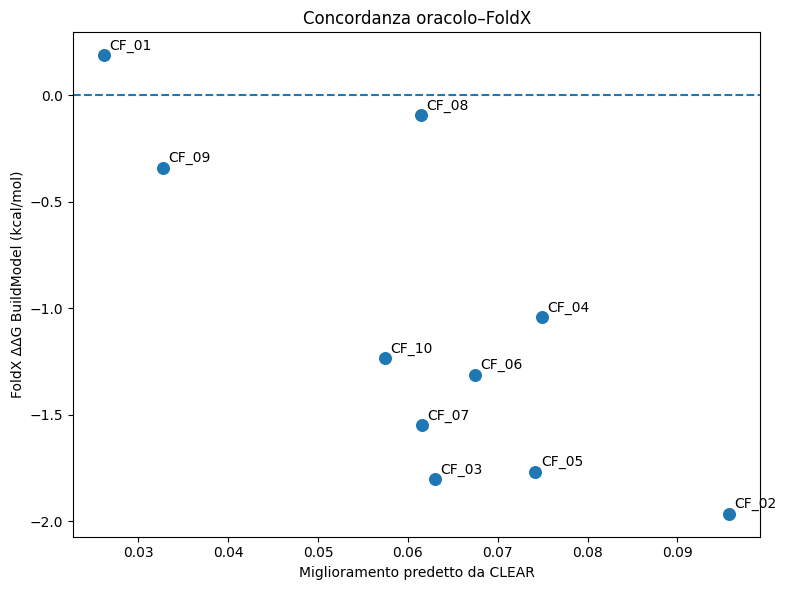

In [26]:
if not valid_correlation.empty:
    plt.figure(figsize=(8, 6))
    plt.scatter(
        valid_correlation[
            "predicted_improvement_vs_seed"
        ],
        valid_correlation[
            "foldx_ddG_total_kcal_mol"
        ],
        s=70,
    )

    for row in valid_correlation.itertuples(index=False):
        plt.annotate(
            row.validation_id,
            (
                row.predicted_improvement_vs_seed,
                row.foldx_ddG_total_kcal_mol,
            ),
            xytext=(4, 4),
            textcoords="offset points",
        )

    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Miglioramento predetto da CLEAR")
    plt.ylabel("FoldX ΔΔG BuildModel (kcal/mol)")
    plt.title("Concordanza oracolo–FoldX")
    plt.tight_layout()
    plt.savefig(
        REPORTS_DIR / "oracle_vs_foldx_ddg.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 18. Ranking energetico-strutturale

Il ranking finale privilegia:

- ΔΔG FoldX favorevole;
- ritenzione dei contatti;
- conservazione hotspot;
- assenza di clash;
- basso RMSD del backbone;
- miglioramento predetto da CLEAR.

FoldX e struttura pesano più della predizione dell'oracolo.


In [27]:
def minmax(series, higher_is_better=True):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )
    valid = values.dropna()

    if valid.empty:
        return pd.Series(
            0.0,
            index=values.index,
        )

    if valid.max() == valid.min():
        result = pd.Series(
            0.5,
            index=values.index,
        )
        result[values.isna()] = 0.0
        return result

    result = (
        values - valid.min()
    ) / (
        valid.max() - valid.min()
    )

    if not higher_is_better:
        result = 1.0 - result

    result[values.isna()] = 0.0
    return result


validation_results["norm_foldx_favorable"] = minmax(
    validation_results[
        "foldx_ddG_total_kcal_mol"
    ],
    higher_is_better=False,
)

validation_results["norm_contact_recall"] = minmax(
    validation_results["native_contact_recall"],
    higher_is_better=True,
)

validation_results["norm_hotspot_preservation"] = minmax(
    validation_results[
        "hotspot_contact_preservation"
    ],
    higher_is_better=True,
)

validation_results["norm_low_rmsd"] = minmax(
    validation_results[
        "peptide_backbone_rmsd_A"
    ],
    higher_is_better=False,
)

validation_results["norm_clear_improvement"] = minmax(
    validation_results[
        "predicted_improvement_vs_seed"
    ],
    higher_is_better=True,
)

validation_results["clash_penalty"] = np.where(
    validation_results[
        "n_atom_clashes_lt_2A"
    ].fillna(np.inf) > 0,
    1.0,
    0.0,
)

validation_results["validation_score"] = (
    0.40
    * validation_results["norm_foldx_favorable"]
    + 0.25
    * validation_results["norm_contact_recall"]
    + 0.15
    * validation_results[
        "norm_hotspot_preservation"
    ]
    + 0.10
    * validation_results["norm_low_rmsd"]
    + 0.10
    * validation_results[
        "norm_clear_improvement"
    ]
    - 0.50
    * validation_results["clash_penalty"]
)

validation_results = validation_results.sort_values(
    [
        "validation_score",
        "foldx_ddG_total_kcal_mol",
    ],
    ascending=[False, True],
).reset_index(drop=True)

validation_results.insert(
    0,
    "validation_rank",
    np.arange(1, len(validation_results) + 1),
)

display(
    validation_results[
        [
            "validation_rank",
            "validation_id",
            "sequence",
            "mutation_labels",
            "foldx_ddG_total_kcal_mol",
            "native_contact_recall",
            "hotspot_contact_preservation",
            "n_atom_clashes_lt_2A",
            "peptide_backbone_rmsd_A",
            "predicted_improvement_vs_seed",
            "validation_score",
        ]
    ]
)

,validation_rank,validation_id,sequence,mutation_labels,foldx_ddG_total_kcal_mol,native_contact_recall,hotspot_contact_preservation,n_atom_clashes_lt_2A,peptide_backbone_rmsd_A,predicted_improvement_vs_seed,validation_score
0,1,CF_02,IGERSQYRELK,C5S;D9E,-1.965180,0.972973,1.0,0,4.628042e-15,0.095755,0.750000
1,2,CF_05,IGERCEYRELK,Q6E;D9E,-1.767060,0.972973,1.0,0,4.628042e-15,0.074191,0.682180
2,3,CF_03,IGERCQYRELK,D9E,-1.802840,0.972973,1.0,0,4.628042e-15,0.062971,0.672702
3,4,CF_06,IGERCQYRELR,D9E;K11R,-1.312510,0.972973,1.0,0,4.628042e-15,0.067425,0.587969
4,5,CF_10,IGERCQYRELQ,D9E;K11Q,-1.234190,0.972973,1.0,0,4.628042e-15,0.057461,0.559090
5,6,CF_04,IGERCQYKELK,R8K;D9E,-1.042900,0.972973,1.0,0,4.628042e-15,0.074910,0.548617
6,7,CF_07,IGERCQYRELE,D9E;K11E,-1.549180,0.945946,1.0,0,4.628042e-15,0.061535,0.498492
7,8,CF_09,IGERSQYRDLK,C5S,-0.340115,1.000000,1.0,0,4.628042e-15,0.032750,0.482393
8,9,CF_08,IGERSEYRDLK,C5S;Q6E,-0.094799,1.000000,1.0,0,4.628042e-15,0.061428,0.478021
9,10,CF_01,IGERCEYKDLK,Q6E;R8K,0.186924,1.000000,1.0,0,4.628042e-15,0.026186,0.375000


## 19. Selezione dei candidati per Rosetta

Criteri minimi:

- modello FoldX disponibile;
- nessun clash;
- ritenzione contatti ≥ 0,85;
- hotspot preservati;
- preferenza per ΔΔG < 0.

Se meno di 5 candidati superano tutti i criteri, il pannello viene completato usando il ranking generale.


In [28]:
strict_pool = validation_results[
    validation_results["model_status"].eq(
        "MODEL_AVAILABLE"
    )
    & validation_results["no_clashes"]
    & validation_results["high_contact_retention"]
    & validation_results["all_hotspots_preserved"]
    & validation_results["foldx_favorable_vs_seed"]
].copy()

selected_for_rosetta = strict_pool.head(
    TOP_N_FOR_ROSETTA
).copy()

if len(selected_for_rosetta) < TOP_N_FOR_ROSETTA:
    fallback = validation_results[
        ~validation_results["validation_id"].isin(
            selected_for_rosetta["validation_id"]
        )
        & validation_results["model_status"].eq(
            "MODEL_AVAILABLE"
        )
        & validation_results["no_clashes"]
    ].head(
        TOP_N_FOR_ROSETTA
        - len(selected_for_rosetta)
    )

    selected_for_rosetta = pd.concat(
        [selected_for_rosetta, fallback],
        ignore_index=True,
    )

selected_for_rosetta.insert(
    0,
    "rosetta_candidate_id",
    [
        f"RC_{index:02d}"
        for index in range(
            1,
            len(selected_for_rosetta) + 1,
        )
    ],
)

display(
    selected_for_rosetta[
        [
            "rosetta_candidate_id",
            "validation_id",
            "sequence",
            "mutation_labels",
            "foldx_ddG_total_kcal_mol",
            "native_contact_recall",
            "hotspot_contact_preservation",
            "peptide_backbone_rmsd_A",
            "validation_score",
        ]
    ]
)

,rosetta_candidate_id,validation_id,sequence,mutation_labels,foldx_ddG_total_kcal_mol,native_contact_recall,hotspot_contact_preservation,peptide_backbone_rmsd_A,validation_score
0,RC_01,CF_02,IGERSQYRELK,C5S;D9E,-1.96518,0.972973,1.0,4.628042e-15,0.750000
1,RC_02,CF_05,IGERCEYRELK,Q6E;D9E,-1.76706,0.972973,1.0,4.628042e-15,0.682180
2,RC_03,CF_03,IGERCQYRELK,D9E,-1.80284,0.972973,1.0,4.628042e-15,0.672702
3,RC_04,CF_06,IGERCQYRELR,D9E;K11R,-1.31251,0.972973,1.0,4.628042e-15,0.587969
4,RC_05,CF_10,IGERCQYRELQ,D9E;K11Q,-1.23419,0.972973,1.0,4.628042e-15,0.559090


## 20. Preparazione dei PDB per Rosetta

In [29]:
rosetta_manifest_rows = []

for row in selected_for_rosetta.itertuples(index=False):
    source_pdb = Path(row.counterfactual_model_pdb)

    if not source_pdb.exists():
        continue

    target_pdb = (
        ROSETTA_PREP_DIR
        / f"{row.rosetta_candidate_id}_{row.validation_id}.pdb"
    )
    shutil.copy2(source_pdb, target_pdb)

    rosetta_manifest_rows.append({
        "rosetta_candidate_id": (
            row.rosetta_candidate_id
        ),
        "validation_id": row.validation_id,
        "sequence": row.sequence,
        "mutation_labels": row.mutation_labels,
        "source_pdb": str(source_pdb),
        "rosetta_input_pdb": str(target_pdb),
        "validation_score": row.validation_score,
    })

rosetta_manifest = pd.DataFrame(
    rosetta_manifest_rows
)

display(rosetta_manifest)

,rosetta_candidate_id,validation_id,sequence,mutation_labels,source_pdb,rosetta_input_pdb,validation_score
0,RC_01,CF_02,IGERSQYRELK,C5S;D9E,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_02_IGERSQYRELK.pdb,outputs/clear_counterfactual_validation_05c/rosetta_candidates/RC_01_CF_02.pdb,0.750000
1,RC_02,CF_05,IGERCEYRELK,Q6E;D9E,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_05_IGERCEYRELK.pdb,outputs/clear_counterfactual_validation_05c/rosetta_candidates/RC_02_CF_05.pdb,0.682180
2,RC_03,CF_03,IGERCQYRELK,D9E,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_03_IGERCQYRELK.pdb,outputs/clear_counterfactual_validation_05c/rosetta_candidates/RC_03_CF_03.pdb,0.672702
3,RC_04,CF_06,IGERCQYRELR,D9E;K11R,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_06_IGERCQYRELR.pdb,outputs/clear_counterfactual_validation_05c/rosetta_candidates/RC_04_CF_06.pdb,0.587969
4,RC_05,CF_10,IGERCQYRELQ,D9E;K11Q,outputs/clear_counterfactual_validation_05c/counterfactual_models/CF_10_IGERCQYRELQ.pdb,outputs/clear_counterfactual_validation_05c/rosetta_candidates/RC_05_CF_10.pdb,0.559090


## 21. Visualizzazioni finali

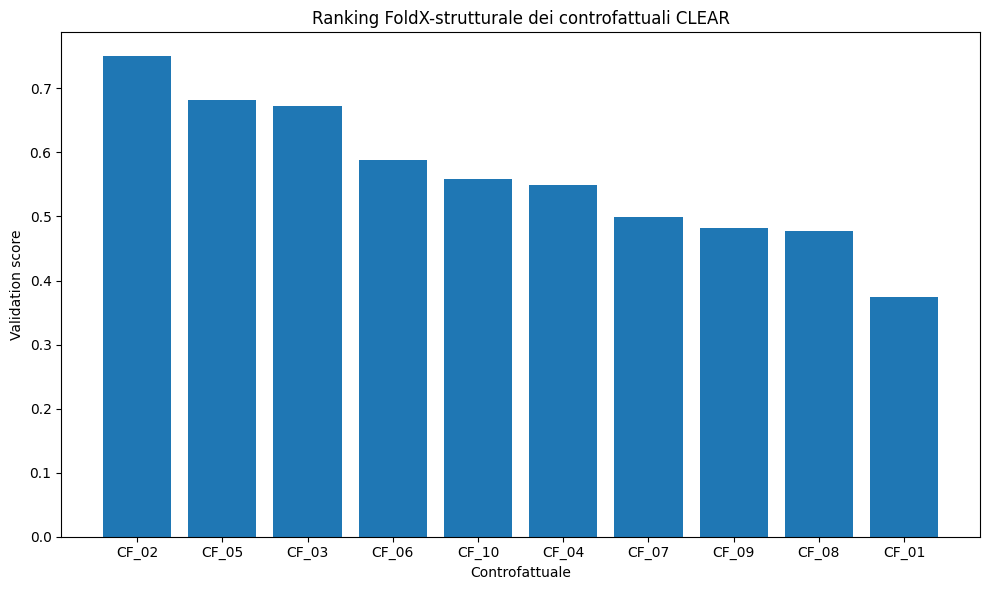

In [30]:
if not validation_results.empty:
    plot_df = validation_results.sort_values(
        "validation_rank"
    )

    plt.figure(figsize=(10, 6))
    plt.bar(
        plot_df["validation_id"],
        plot_df["validation_score"],
    )
    plt.xlabel("Controfattuale")
    plt.ylabel("Validation score")
    plt.title("Ranking FoldX-strutturale dei controfattuali CLEAR")
    plt.tight_layout()
    plt.savefig(
        REPORTS_DIR / "validation_ranking.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

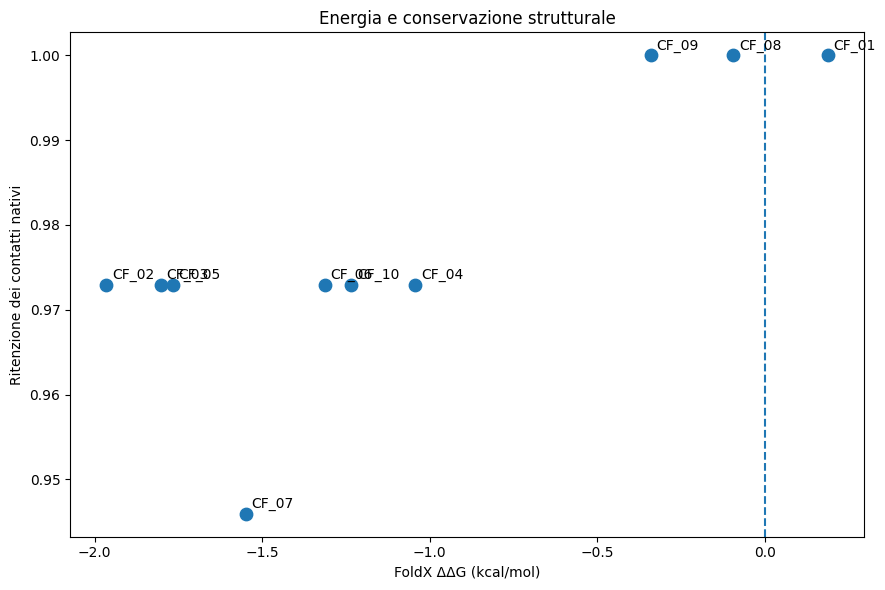

In [31]:
if not validation_results.empty:
    plt.figure(figsize=(9, 6))
    plt.scatter(
        validation_results[
            "foldx_ddG_total_kcal_mol"
        ],
        validation_results[
            "native_contact_recall"
        ],
        s=80,
    )

    for row in validation_results.itertuples(index=False):
        plt.annotate(
            row.validation_id,
            (
                row.foldx_ddG_total_kcal_mol,
                row.native_contact_recall,
            ),
            xytext=(4, 4),
            textcoords="offset points",
        )

    plt.axvline(0.0, linestyle="--")
    plt.xlabel("FoldX ΔΔG (kcal/mol)")
    plt.ylabel("Ritenzione dei contatti nativi")
    plt.title("Energia e conservazione strutturale")
    plt.tight_layout()
    plt.savefig(
        REPORTS_DIR / "foldx_vs_contact_recall.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

## 22. Esportazione

In [32]:
VALIDATION_RESULTS_CSV = (
    RESULT_DIR
    / "clear_counterfactual_foldx_structural_validation.csv"
)
ROSETTA_SELECTION_CSV = (
    RESULT_DIR
    / "clear_candidates_selected_for_rosetta.csv"
)
ROSETTA_MANIFEST_CSV = (
    ROSETTA_PREP_DIR
    / "rosetta_input_manifest.csv"
)
MODEL_MANIFEST_CSV = (
    RESULT_DIR / "counterfactual_model_manifest.csv"
)
RUN_METADATA_JSON = (
    RESULT_DIR / "05c_run_metadata.json"
)

validation_results.to_csv(
    VALIDATION_RESULTS_CSV,
    index=False,
)
selected_for_rosetta.to_csv(
    ROSETTA_SELECTION_CSV,
    index=False,
)
rosetta_manifest.to_csv(
    ROSETTA_MANIFEST_CSV,
    index=False,
)
model_manifest.to_csv(
    MODEL_MANIFEST_CSV,
    index=False,
)

metadata = {
    "seed_sequence": SEED_SEQUENCE,
    "native_pdb": str(NATIVE_F0010_PDB),
    "n_counterfactuals": len(validation_panel),
    "n_models_available": int(
        model_manifest["model_status"]
        .eq("MODEL_AVAILABLE")
        .sum()
    ),
    "foldx_complete": bool(
        final_foldx_status["complete"]
    ),
    "oracle_foldx_pearson": (
        None if pd.isna(pearson_corr)
        else float(pearson_corr)
    ),
    "oracle_foldx_spearman": (
        None if pd.isna(spearman_corr)
        else float(spearman_corr)
    ),
    "n_selected_for_rosetta": len(
        selected_for_rosetta
    ),
    "ranking_weights": {
        "foldx": 0.40,
        "contact_recall": 0.25,
        "hotspot_preservation": 0.15,
        "low_rmsd": 0.10,
        "clear_improvement": 0.10,
        "clash_penalty": 0.50,
    },
    "warning": (
        "FoldX BuildModel validation is performed in the native-like "
        "pose and requires Rosetta refinement for stronger structural evidence."
    ),
}

RUN_METADATA_JSON.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)

for path in [
    VALIDATION_RESULTS_CSV,
    ROSETTA_SELECTION_CSV,
    ROSETTA_MANIFEST_CSV,
    MODEL_MANIFEST_CSV,
    RUN_METADATA_JSON,
]:
    print("Salvato:", path.resolve())

Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c/clear_counterfactual_foldx_structural_validation.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c/clear_candidates_selected_for_rosetta.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c/rosetta_candidates/rosetta_input_manifest.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c/counterfactual_model_manifest.csv
Salvato: /Users/robertobruzzese/Desktop/venv/outputs/clear_counterfactual_validation_05c/05c_run_metadata.json


## 23. Report automatico

In [33]:
best_row = (
    validation_results.iloc[0]
    if not validation_results.empty
    else None
)

report = f'''# 05c — CLEAR counterfactual FoldX and structural validation

## Seed
- Sequenza: `{SEED_SEQUENCE}`
- Complesso nativo: `{NATIVE_F0010_PDB}`

## Pannello
- Controfattuali valutati: {len(validation_panel)}
- Modelli FoldX disponibili: {int(model_manifest["model_status"].eq("MODEL_AVAILABLE").sum())}
- FoldX completo: {final_foldx_status["complete"]}

## Concordanza oracolo–FoldX
- Pearson: {pearson_corr}
- Spearman: {spearman_corr}

## Miglior candidato validato
- ID: {best_row["validation_id"] if best_row is not None else "N/A"}
- Sequenza: `{best_row["sequence"] if best_row is not None else "N/A"}`
- Mutazioni: {best_row["mutation_labels"] if best_row is not None else "N/A"}
- FoldX ΔΔG: {best_row["foldx_ddG_total_kcal_mol"] if best_row is not None else float("nan"):.6f}
- Native contact recall: {best_row["native_contact_recall"] if best_row is not None else float("nan"):.6f}
- Hotspot preservation: {best_row["hotspot_contact_preservation"] if best_row is not None else float("nan"):.6f}
- Backbone RMSD: {best_row["peptide_backbone_rmsd_A"] if best_row is not None else float("nan"):.6f}
- Validation score: {best_row["validation_score"] if best_row is not None else float("nan"):.6f}

## Selezione Rosetta
- Candidati selezionati: {len(selected_for_rosetta)}
- Manifest: `{ROSETTA_MANIFEST_CSV}`

## Output principale
`{VALIDATION_RESULTS_CSV}`

## Interpretazione
La selezione combina FoldX, contatti, hotspot, clash, RMSD e predizione CLEAR. I candidati selezionati devono ancora essere sottoposti a FlexPepDock prima di concludere che siano migliori del seed.
'''

REPORT_PATH = REPORTS_DIR / "05c_validation_report.md"
REPORT_PATH.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("Report:", REPORT_PATH.resolve())

# 05c — CLEAR counterfactual FoldX and structural validation

## Seed
- Sequenza: `IGERCQYRDLK`
- Complesso nativo: `/Users/robertobruzzese/Desktop/venv/outputs/short_peptide_guided_docking_03c/rosetta_flexpepdock/inputs/F0010.pdb`

## Pannello
- Controfattuali valutati: 10
- Modelli FoldX disponibili: 10
- FoldX completo: True

## Concordanza oracolo–FoldX
- Pearson: -0.7737572035791113
- Spearman: -0.7090909090909091

## Miglior candidato validato
- ID: CF_02
- Sequenza: `IGERSQYRELK`
- Mutazioni: C5S;D9E
- FoldX ΔΔG: -1.965180
- Native contact recall: 0.972973
- Hotspot preservation: 1.000000
- Backbone RMSD: 0.000000
- Validation score: 0.750000

## Selezione Rosetta
- Candidati selezionati: 5
- Manifest: `outputs/clear_counterfactual_validation_05c/rosetta_candidates/rosetta_input_manifest.csv`

## Output principale
`outputs/clear_counterfactual_validation_05c/clear_counterfactual_foldx_structural_validation.csv`

## Interpretazione
La selezione combina FoldX, contatti, hotspot, c

## 24. Passaggio successivo

Se il pannello contiene candidati con:

- ΔΔG FoldX favorevole;
- ritenzione dei contatti elevata;
- hotspot preservati;
- assenza di clash;

procedere con:

```text
05d_CLEAR_Counterfactual_FlexPepDock_Refinement.ipynb
```

Il notebook successivo dovrà confrontare:

- F0010;
- il controfattuale minimo `D9E`;
- il miglior candidato doppio;
- l'unico candidato nuovo rispetto al dataset 04c;
- eventuali altri candidati selezionati dal ranking 05c.
